# Notebook 03 — EDA / Descriptive Analytics

**Tier:** 1 — Descriptive (What happened?)  
**Purpose:** Describe ride volumes, revenue, service quality, locations, and payments.  
**Input:** `outputs/cleaned_data.parquet`  
**Output:** `outputs/feature_store.parquet`, charts in `outputs/plots/03_*`  
**Caveats:**  
- Revenue is reported as **Gross Booking Value (GBV)** — the fare paid by the customer.  
- Net revenue, driver payout, commission, and contribution margin are **unavailable** (no cost fields in dataset).  
- Per-customer cumulative revenue is reported as **Observed Customer Value (OCV)** — NOT LTV.

In [3]:
import sys
sys.path.insert(0, '..')

import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")

warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)

from src.data_loader import load_clean
from src.features import build_feature_store

df_clean = load_clean()
df = build_feature_store(df_clean, save=True)
print(f'Feature store shape: {df.shape}')

completed = df[df['is_completed']].copy()
print(f'Completed rides: {len(completed):,}')

[OK] Feature store written to outputs\feature_store.parquet  shape=(150000, 46)
Feature store shape: (150000, 46)
Completed rides: 93,000


## 3.1 Ride Volume Overview

In [4]:
total = len(df)
n_completed = (df['Booking Status'] == 'Completed').sum()
n_canc_cust = (df['Booking Status'] == 'Cancelled by Customer').sum()
n_canc_drv  = (df['Booking Status'] == 'Cancelled by Driver').sum()
n_no_drv    = (df['Booking Status'] == 'No Driver Found').sum()
n_incomplete = (df['Booking Status'] == 'Incomplete').sum()

print(f'Total bookings         : {total:,}')
print(f'Completed              : {n_completed:,}  ({n_completed/total*100:.1f}%)')
print(f'Cancelled by Customer  : {n_canc_cust:,}  ({n_canc_cust/total*100:.1f}%)')
print(f'Cancelled by Driver    : {n_canc_drv:,}  ({n_canc_drv/total*100:.1f}%)')
print(f'No Driver Found        : {n_no_drv:,}  ({n_no_drv/total*100:.1f}%)')
print(f'Incomplete             : {n_incomplete:,}  ({n_incomplete/total*100:.1f}%)')

total_gbv = completed['Booking Value'].sum()
avg_fare  = completed['Booking Value'].mean()
print(f'\nTotal Gross Booking Value (GBV) : ₹{total_gbv:,.0f}')
print(f'Avg fare per completed ride      : ₹{avg_fare:.0f}')

Total bookings         : 150,000
Completed              : 93,000  (62.0%)
Cancelled by Customer  : 10,500  (7.0%)
Cancelled by Driver    : 27,000  (18.0%)
No Driver Found        : 10,500  (7.0%)
Incomplete             : 9,000  (6.0%)

Total Gross Booking Value (GBV) : ₹47,260,574
Avg fare per completed ride      : ₹508


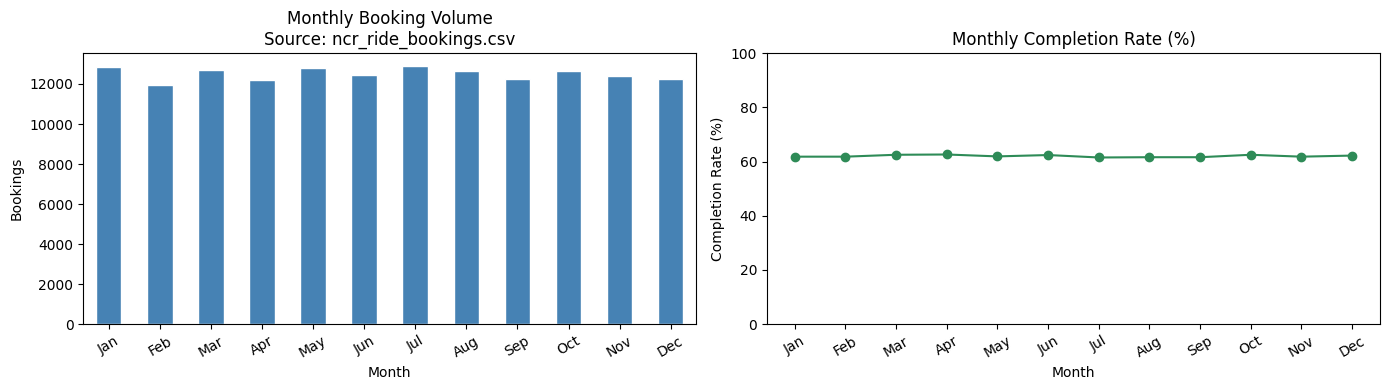

In [5]:
# Monthly booking volume
monthly_vol = df.groupby('month').size().rename('bookings')
monthly_comp = completed.groupby('month').size().rename('completed')
monthly = pd.concat([monthly_vol, monthly_comp], axis=1)
monthly['completion_rate'] = (monthly['completed'] / monthly['bookings'] * 100).round(1)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
monthly['bookings'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Monthly Booking Volume\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Month')
ax.set_ylabel('Bookings')
ax.set_xticklabels(month_labels, rotation=30)

ax = axes[1]
monthly['completion_rate'].plot(kind='line', ax=ax, marker='o', color='seagreen')
ax.set_title('Monthly Completion Rate (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)
ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig('outputs/plots/03_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Booking Status Breakdown by Month

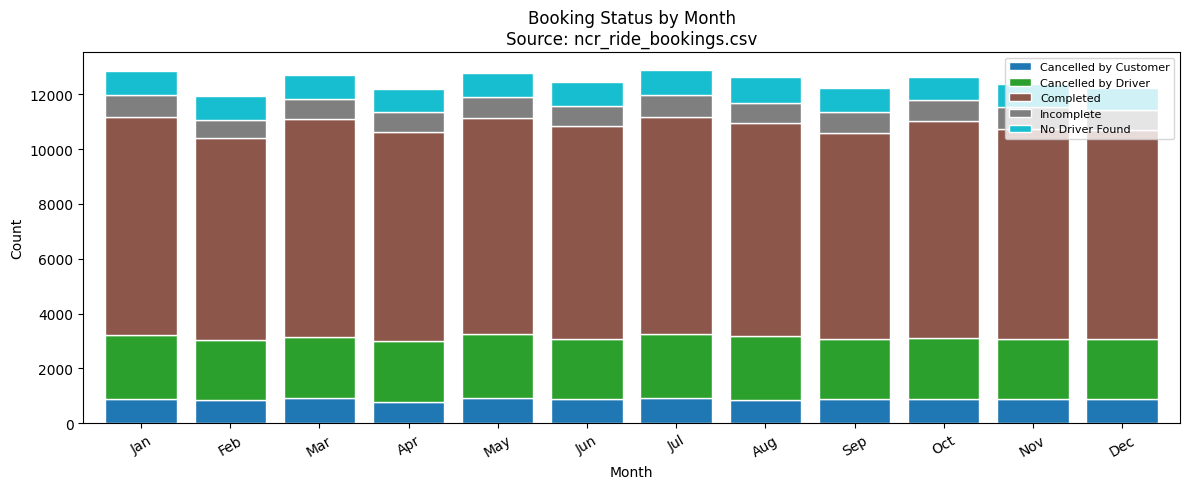

In [6]:
status_month = df.groupby(['month', 'Booking Status'], observed=True).size().unstack(fill_value=0)
status_month.index = month_labels

fig, ax = plt.subplots(figsize=(12, 5))
status_month.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Booking Status by Month\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig('outputs/plots/03_status_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Vehicle Type Analysis

In [7]:
vehicle_stats = df.groupby('Vehicle Type', observed=True).agg(
    total_bookings=('Booking ID', 'count'),
    completed=('is_completed', 'sum'),
    avg_booking_value=('Booking Value', 'mean'),
    avg_ride_distance=('Ride Distance', 'mean'),
    avg_vtat=('Avg VTAT', 'mean'),
).round(2)
vehicle_stats['completion_rate_pct'] = (vehicle_stats['completed'] / vehicle_stats['total_bookings'] * 100).round(1)
vehicle_stats = vehicle_stats.sort_values('total_bookings', ascending=False)
print('Vehicle Type Statistics:')
print(vehicle_stats.to_string())
vehicle_stats.to_csv('outputs/reports/vehicle_stats.csv')

Vehicle Type Statistics:
               total_bookings  completed  avg_booking_value  avg_ride_distance  avg_vtat  completion_rate_pct
Vehicle Type                                                                                                 
Auto                    37419      23155             506.73              24.62      8.45                 61.9
Go Mini                 29806      18549             507.68              24.61      8.47                 62.2
Go Sedan                27141      16676             511.50              24.61      8.40                 61.4
Bike                    22517      14034             510.20              24.65      8.50                 62.3
Premier Sedan           18111      11252             509.57              24.60      8.44                 62.1
eBike                   10557       6551             503.90              24.99      8.48                 62.1
Uber XL                  4449       2783             501.82              24.40      8.58       

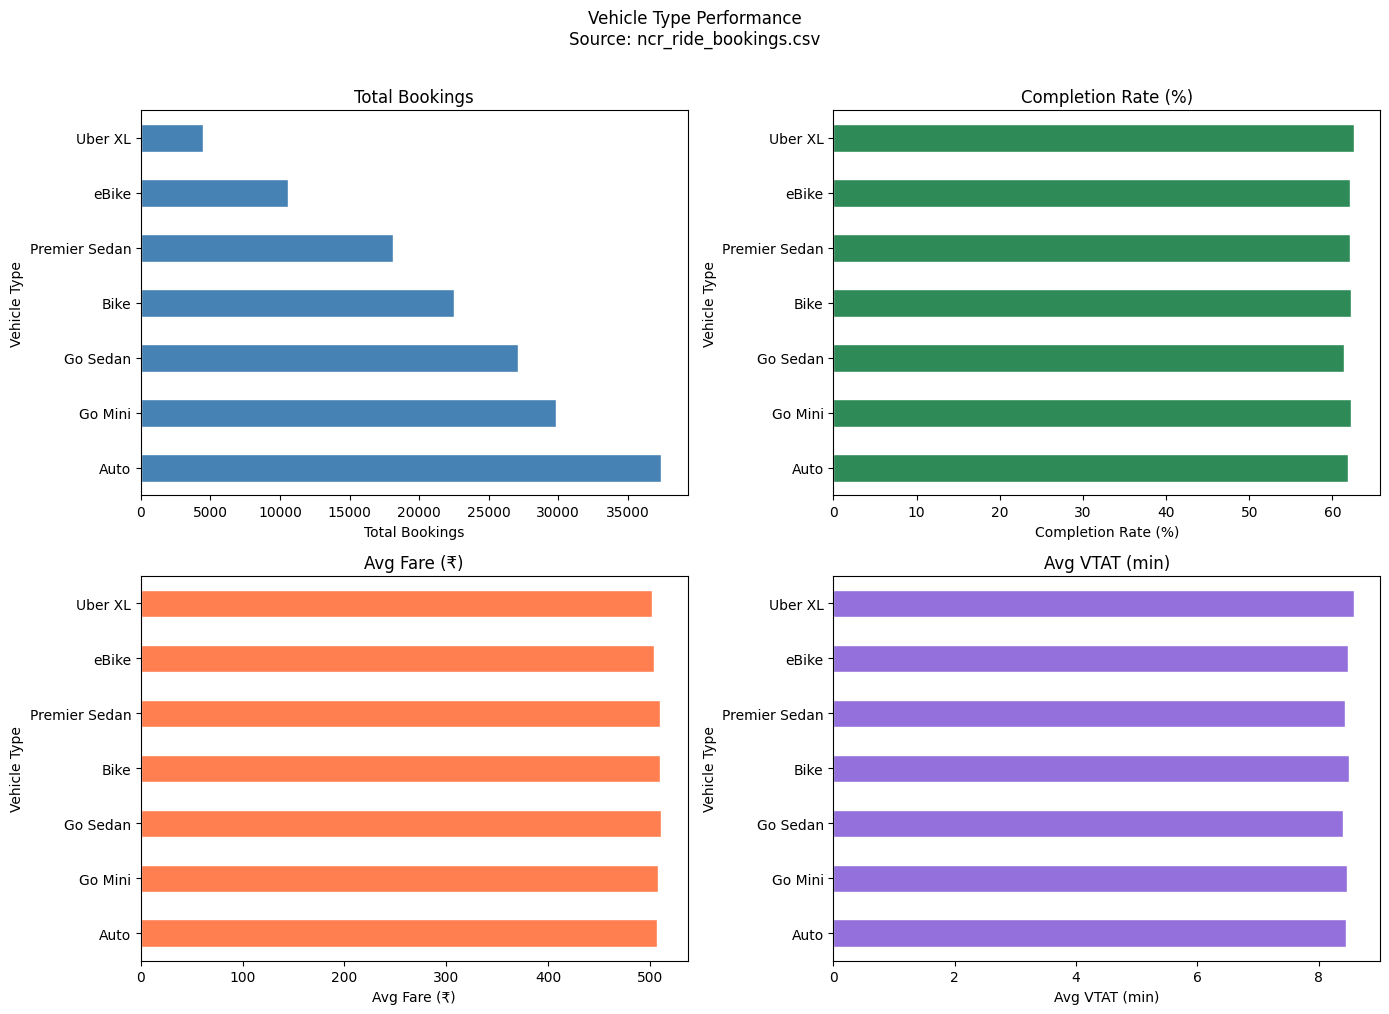

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('total_bookings', 'Total Bookings', 'steelblue'),
    ('completion_rate_pct', 'Completion Rate (%)', 'seagreen'),
    ('avg_booking_value', 'Avg Fare (₹)', 'coral'),
    ('avg_vtat', 'Avg VTAT (min)', 'mediumpurple'),
]
for ax, (col, title, color) in zip(axes.flatten(), metrics):
    vehicle_stats[col].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(title)
fig.suptitle('Vehicle Type Performance\nSource: ncr_ride_bookings.csv', y=1.01)
plt.tight_layout()
fig.savefig('outputs/plots/03_vehicle_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Revenue Overview (Gross Booking Value)

> ⚠️ All revenue figures below are **Gross Booking Value (GBV)** — the fare paid by the customer.  
> Net revenue, driver payout, commission, and margin are **unavailable** (no cost fields in dataset).

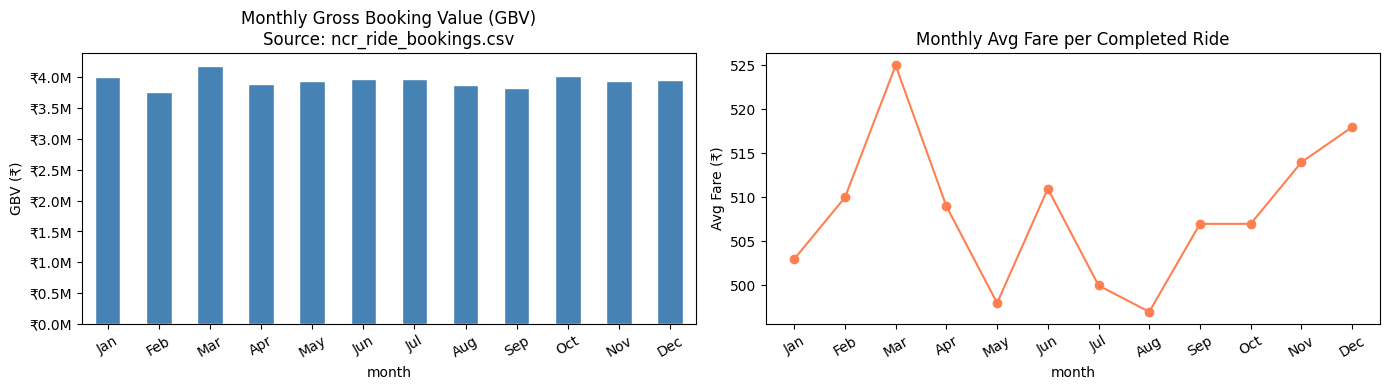

In [9]:
monthly_gbv = completed.groupby('month')['Booking Value'].sum()
monthly_avg_fare = completed.groupby('month')['Booking Value'].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
monthly_gbv.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Monthly Gross Booking Value (GBV)\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('GBV (₹)')
ax.set_xticklabels(month_labels, rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

ax = axes[1]
monthly_avg_fare.plot(kind='line', marker='o', ax=ax, color='coral')
ax.set_title('Monthly Avg Fare per Completed Ride')
ax.set_ylabel('Avg Fare (₹)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)

plt.tight_layout()
fig.savefig('outputs/plots/03_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# GBV by vehicle type
gbv_vehicle = completed.groupby('Vehicle Type', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('GBV by Vehicle Type:')
print(gbv_vehicle.apply(lambda x: f'₹{x:,.0f}').to_string())

# GBV by payment method
gbv_payment = completed.groupby('Payment Method', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('\nGBV by Payment Method:')
print(gbv_payment.apply(lambda x: f'₹{x:,.0f}').to_string())

GBV by Vehicle Type:
Vehicle Type
Auto             ₹11,727,615
Go Mini           ₹9,411,418
Go Sedan          ₹8,538,560
Bike              ₹7,144,913
Premier Sedan     ₹5,733,655
eBike             ₹3,298,157
Uber XL           ₹1,406,256

GBV by Payment Method:
Payment Method
UPI            ₹21,274,591
Cash           ₹11,756,071
Uber Wallet     ₹5,669,070
Credit Card     ₹4,753,767
Debit Card      ₹3,807,075


## 3.5 Service Quality Overview

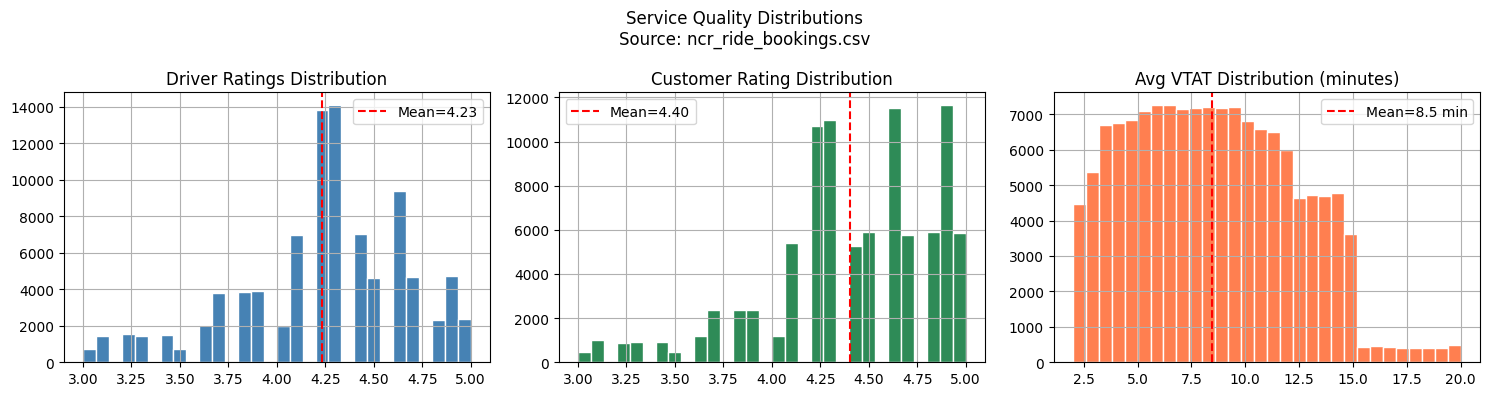

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
completed['Driver Ratings'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(completed['Driver Ratings'].mean(), color='red', linestyle='--', label=f"Mean={completed['Driver Ratings'].mean():.2f}")
ax.set_title('Driver Ratings Distribution')
ax.legend()

ax = axes[1]
completed['Customer Rating'].dropna().hist(bins=30, ax=ax, color='seagreen', edgecolor='white')
ax.axvline(completed['Customer Rating'].mean(), color='red', linestyle='--', label=f"Mean={completed['Customer Rating'].mean():.2f}")
ax.set_title('Customer Rating Distribution')
ax.legend()

ax = axes[2]
df['Avg VTAT'].dropna().hist(bins=30, ax=ax, color='coral', edgecolor='white')
ax.axvline(df['Avg VTAT'].mean(), color='red', linestyle='--', label=f"Mean={df['Avg VTAT'].mean():.1f} min")
ax.set_title('Avg VTAT Distribution (minutes)')
ax.legend()

fig.suptitle('Service Quality Distributions\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_service_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Top Locations & Routes

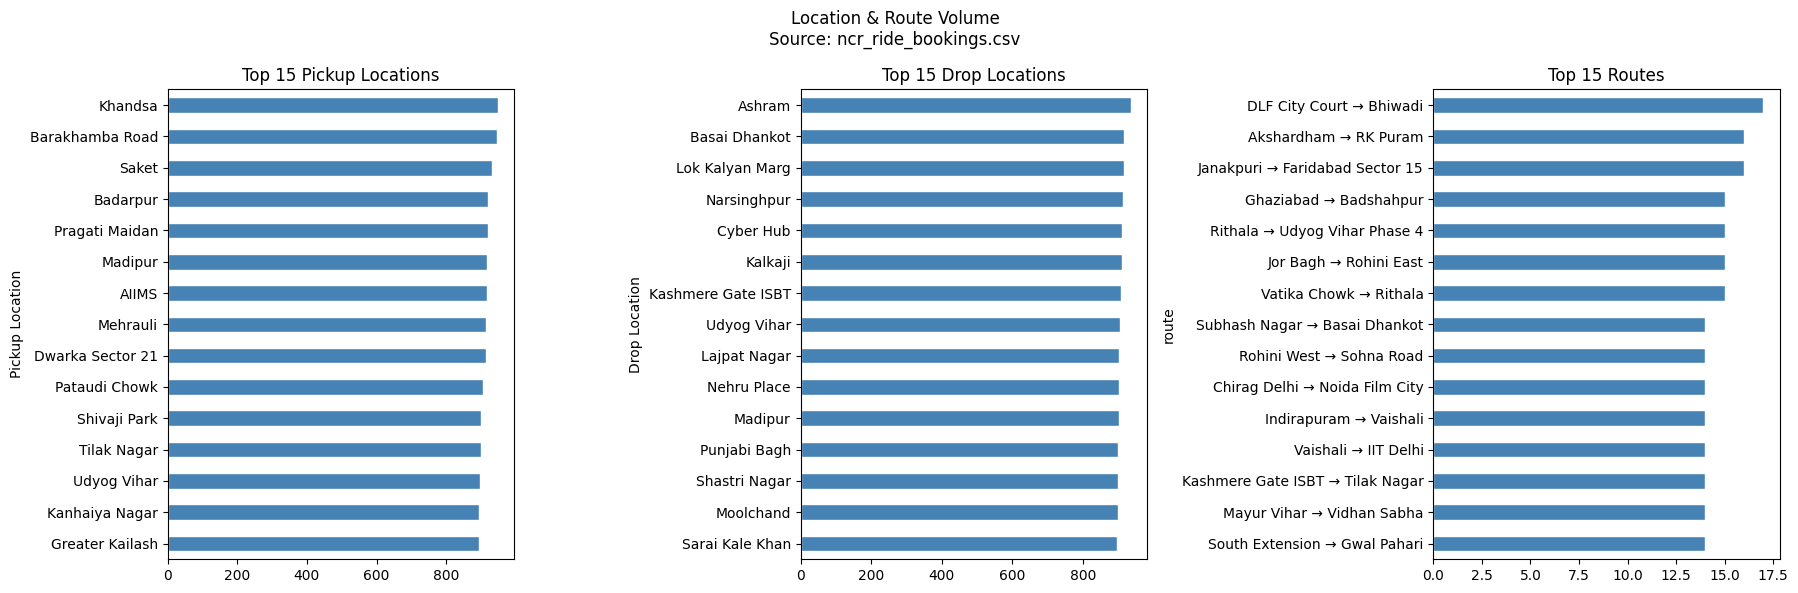

In [12]:
top_pickup = df['Pickup Location'].value_counts().head(15)
top_drop   = df['Drop Location'].value_counts().head(15)
top_routes = df['route'].value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, data, title in zip(axes,
    [top_pickup, top_drop, top_routes],
    ['Top 15 Pickup Locations', 'Top 15 Drop Locations', 'Top 15 Routes']):
    data.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.invert_yaxis()
fig.suptitle('Location & Route Volume\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Payment Method Mix

Payment method distribution (completed rides):
Payment Method
UPI            41834
Cash           23114
Uber Wallet    11206
Credit Card     9320
Debit Card      7526


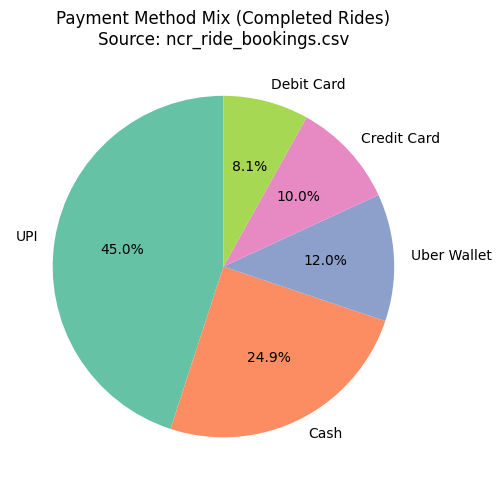

In [13]:
payment_counts = completed['Payment Method'].value_counts()
print('Payment method distribution (completed rides):')
print(payment_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
       startangle=90, colors=plt.cm.Set2.colors[:len(payment_counts)])
ax.set_title('Payment Method Mix (Completed Rides)\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_payment_mix.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- All revenue is GBV only. Net revenue, driver payout, commission, operating cost, and contribution margin cannot be calculated (no cost data in dataset).
- OCV (Observed Customer Value) refers to total fare paid within the observation window — it is not LTV and makes no forward projection.
- CAC, ROAS, and LTV are unavailable.